<a href="https://colab.research.google.com/github/chiragpatel11226/machinelearningjournetpart1/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [191]:
!wget https://raw.githubusercontent.com/chiragpatel11226/machinelearningjournetpart1/main/insurance.csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

--2026-08-22 10:46:05--  https://raw.githubusercontent.com/chiragpatel11226/machinelearningjournetpart1/main/insurance.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 55628 (54K) [text/plain]
Saving to: ‘insurance.csv.2’

insurance.csv.2     100%[===================>]  54.32K  --.-KB/s    in 0.01s   

2026-08-22 10:46:05 (4.84 MB/s) - ‘insurance.csv.2’ saved [55628/55628]



In [192]:
df=pd.read_csv('insurance.csv')

In [193]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [194]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [195]:
df.shape

(1338, 7)

In [196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [197]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [198]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


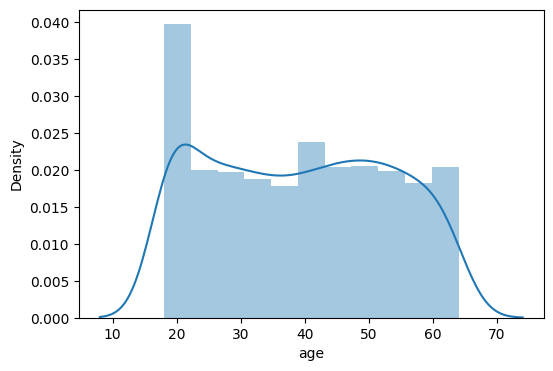

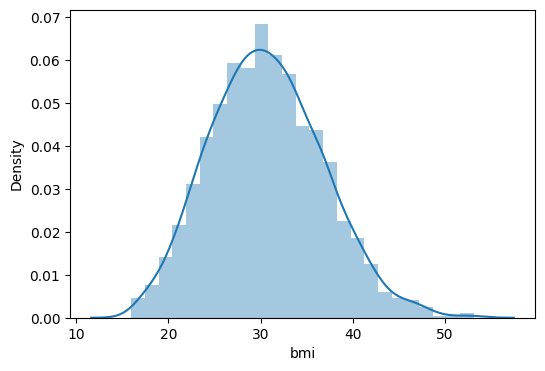

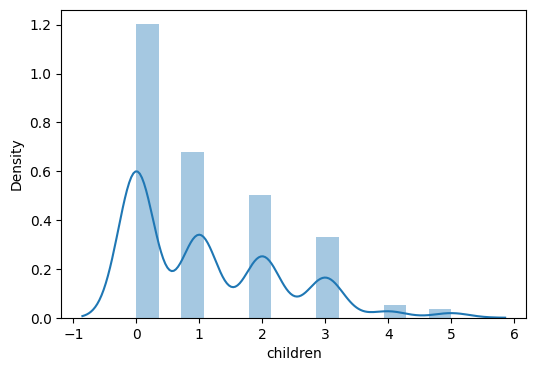

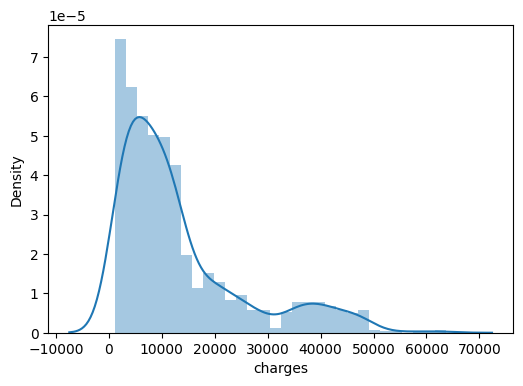

In [199]:
numeric_columns= ['age',  'bmi', 'children', 'charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.distplot(df[col])
    plt.show()

In [200]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

<Axes: xlabel='children', ylabel='count'>

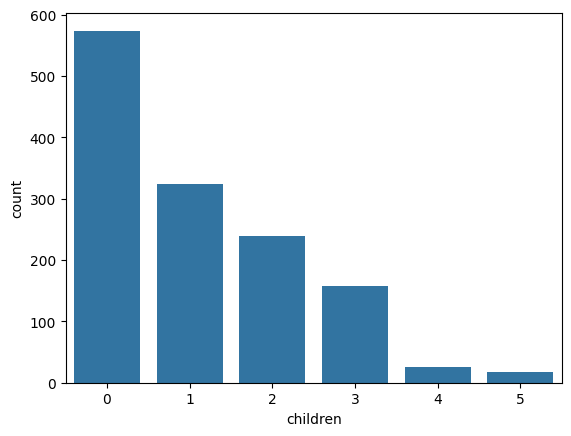

In [201]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

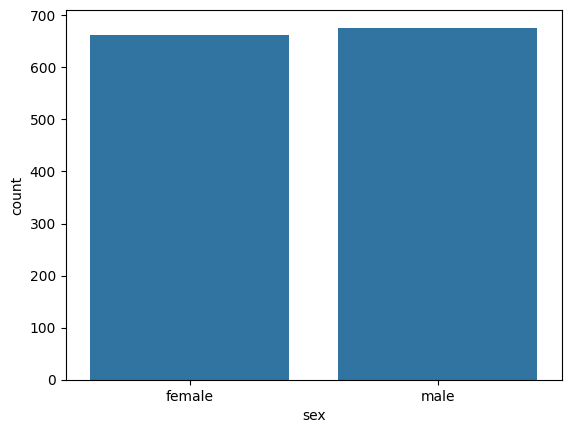

In [202]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

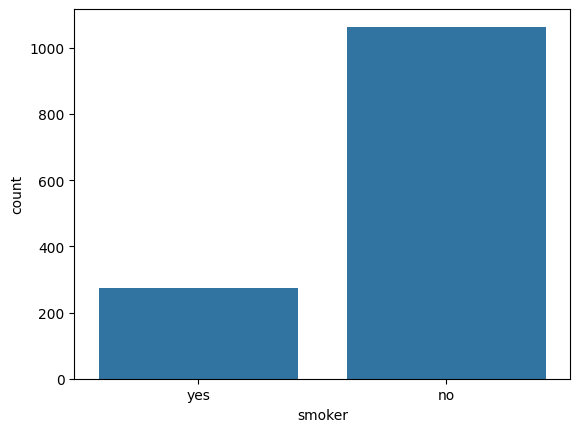

In [203]:
sns.countplot(x=df['smoker'])

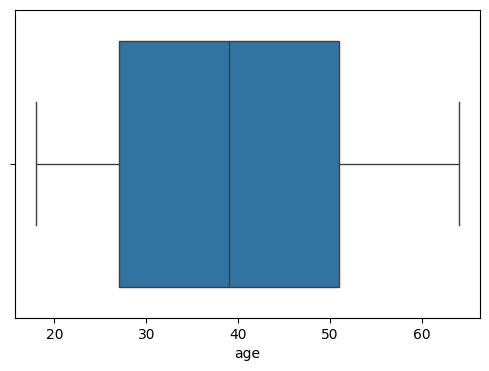

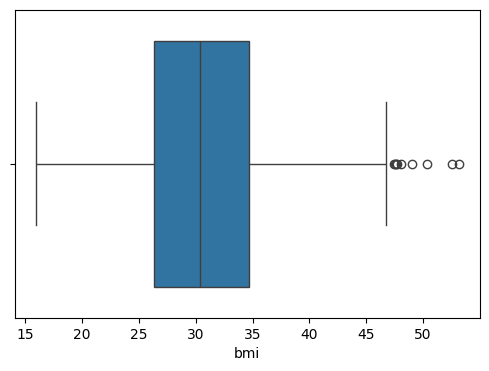

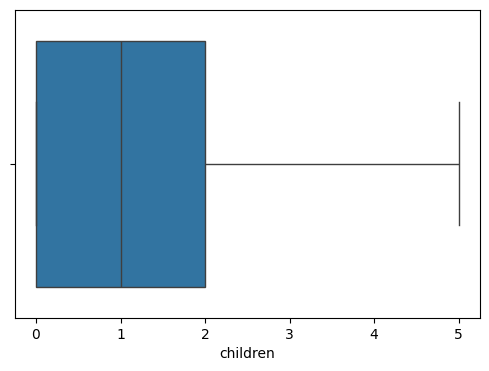

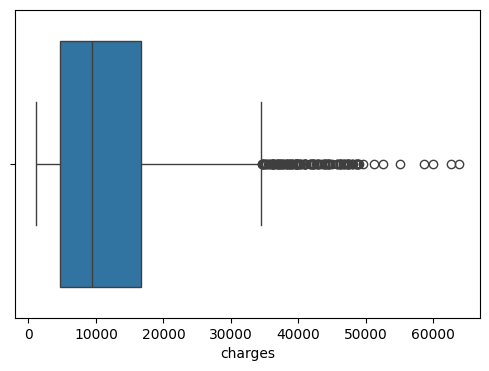

In [204]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.show()

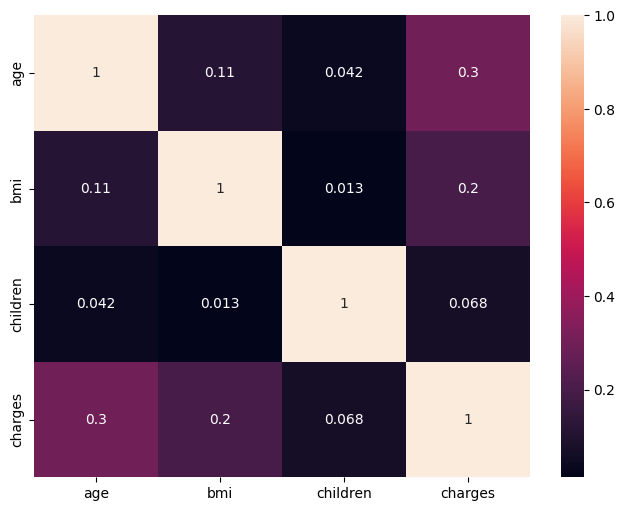

In [205]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_columns].corr(),annot=True)
plt.show()

data cleaning and preprocessing


In [206]:
df_cleaned=df.copy()

In [207]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [208]:
df_cleaned.drop_duplicates(inplace= True)

In [209]:
df_cleaned['sex'].value_counts()

,count
sex,
male,675
female,662


In [210]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male':1,'female':0})

In [211]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,yes,southwest,16884.92400
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520


In [212]:
df_cleaned['smoker']=df_cleaned['smoker'].map({'yes':1,'no':0})

In [213]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [214]:
df_cleaned['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [215]:
df_cleaned.rename(columns={'sex':'is_male',  'smoker':'is_smoker'},inplace=True)

In [216]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [217]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['region'])

In [218]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,0,1725.55230,False,False,True,False
2,28,1,33.000,3,0,4449.46200,False,False,True,False
3,33,1,22.705,0,0,21984.47061,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False


In [219]:
df_cleaned=df_cleaned.astype(int)

In [220]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27,0,1,16884,0,0,0,1
1,18,1,33,1,0,1725,0,0,1,0
2,28,1,33,3,0,4449,0,0,1,0
3,33,1,22,0,0,21984,0,1,0,0
4,32,1,28,0,0,3866,0,1,0,0


feature engineering and extraction

<Axes: xlabel='bmi', ylabel='Count'>

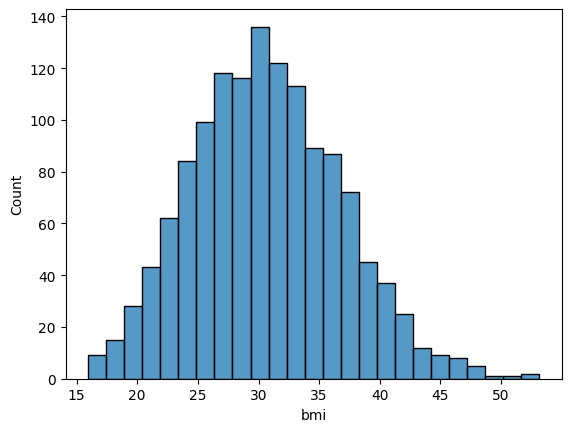

In [221]:
sns.histplot(df['bmi'])

In [222]:
df_cleaned['bmi_category']=pd.cut(df_cleaned['bmi'],bins=[0,18.5,24.9,29.9,100],labels=['underweight','healthy','overweight','obese'])

In [223]:
df_cleaned.head()


,age,is_male,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,0,27,0,1,16884,0,0,0,1,overweight
1,18,1,33,1,0,1725,0,0,1,0,obese
2,28,1,33,3,0,4449,0,0,1,0,obese
3,33,1,22,0,0,21984,0,1,0,0,healthy
4,32,1,28,0,0,3866,0,1,0,0,overweight


In [224]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi_category'])

In [225]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_healthy,bmi_category_overweight,bmi_category_obese
0,19,0,27,0,1,16884,0,0,0,1,False,False,True,False
1,18,1,33,1,0,1725,0,0,1,0,False,False,False,True
2,28,1,33,3,0,4449,0,0,1,0,False,False,False,True
3,33,1,22,0,0,21984,0,1,0,0,False,True,False,False
4,32,1,28,0,0,3866,0,1,0,0,False,False,True,False


In [226]:
df_cleaned=df_cleaned.astype(int)

In [227]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_healthy,bmi_category_overweight,bmi_category_obese
0,19,0,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,1,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,1,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,1,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,1,28,0,0,3866,0,1,0,0,0,0,1,0


In [228]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scaler=StandardScaler()
df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])
df_cleaned

,age,is_male,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_healthy,bmi_category_overweight,bmi_category_obese
0,-1.440418,0,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0
1,-1.511647,1,0.462463,-0.079442,0,1725,0,0,1,0,0,0,0,1
2,-0.799350,1,0.462463,1.580143,0,4449,0,0,1,0,0,0,0,1
3,-0.443201,1,-1.334960,-0.909234,0,21984,0,1,0,0,0,1,0,0
4,-0.514431,1,-0.354547,-0.909234,0,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,1,-0.027743,1.580143,0,10600,0,1,0,0,0,0,0,1
1334,-1.511647,0,0.135659,-0.909234,0,2205,1,0,0,0,0,0,0,1
1335,-1.511647,0,0.952670,-0.909234,0,1629,0,0,1,0,0,0,0,1
1336,-1.297958,0,-0.844753,-0.909234,0,2007,0,0,0,1,0,0,1,0


In [229]:
from scipy.stats import pearsonr
selected_columns=['age','bmi','children','is_male','is_smoker','region_northeast','region_northwest','region_southeast','region_southwest','bmi_category_healthy','bmi_category_obese','bmi_category_overweight','bmi_category_obese']

correlation= {
     feature: pearsonr(df_cleaned[feature],df_cleaned['charges'])[0]
     for feature in selected_columns
}
correlation_df=pd.DataFrame(list(correlation.items()),columns=['feature','correlation'])
correlation_df.sort_values(by='correlation',ascending=False,inplace=True)



In [230]:
correlation_df

,feature,correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_obese,0.200348
1,bmi,0.196236
7,region_southeast,0.073577
2,children,0.067390
3,is_male,0.058046
5,region_northeast,0.005946
6,region_northwest,-0.038695
8,region_southwest,-0.043637


In [231]:
cat_features=['is_male','is_smoker','region_northeast',
              'region_northwest','region_southeast','region_southwest',
              'bmi_category_healthy','bmi_category_obese','bmi_category_overweight','bmi_category_obese']

In [232]:
from scipy.stats import chi2_contingency
import pandas as pd
alpha=0.05
df_cleaned["charge_binned"] = pd.qcut(df_cleaned["charges"], q=4, labels=False)
chi2_results = {}
for col in cat_features:
    contingency_table = pd.crosstab(df_cleaned[col], df_cleaned["charge_binned"])
    chi2_stat, p_value, _, _ = chi2_contingency(contingency_table)
    decision ='reject null (keep feature )' if p_value < alpha else 'accept null (drop feature)'
    chi2_results[col] = {"chi2_stat": chi2_stat, "p_value": p_value, "decision": decision}

chi2_results_df = pd.DataFrame(chi2_results).T
chi2_results_df = chi2_results_df.sort_values(by="p_value")
print(chi2_results_df)

                          chi2_stat   p_value                     decision
is_smoker                848.219178       0.0  reject null (keep feature )
region_southeast          15.998167  0.001135  reject null (keep feature )
is_male                   10.258784   0.01649  reject null (keep feature )
bmi_category_obese         8.515711  0.036473  reject null (keep feature )
region_northeast           6.438442  0.092122   accept null (drop feature)
region_southwest           5.091893  0.165191   accept null (drop feature)
bmi_category_overweight     4.25149  0.235557   accept null (drop feature)
bmi_category_healthy       3.708088   0.29476   accept null (drop feature)
region_northwest            1.13424  0.768815   accept null (drop feature)


In [233]:
final_df=df_cleaned.drop(['region_northeast',"charge_binned",'region_northwest','region_southwest','bmi_category_healthy','bmi_category_obese','bmi_category_overweight'],axis=1)
final_df

,age,is_male,bmi,children,is_smoker,charges,region_southeast,bmi_category_underweight
0,-1.440418,0,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,1,0.462463,-0.079442,0,1725,1,0
2,-0.799350,1,0.462463,1.580143,0,4449,1,0
3,-0.443201,1,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,1,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,1,-0.027743,1.580143,0,10600,0,0
1334,-1.511647,0,0.135659,-0.909234,0,2205,0,0
1335,-1.511647,0,0.952670,-0.909234,0,1629,1,0
1336,-1.297958,0,-0.844753,-0.909234,0,2007,0,0


In [234]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
X=final_df.drop('charges',axis=1)
y=final_df['charges']

In [235]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [236]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [237]:
y_pred=model.predict(X_test)

In [238]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(mse)
print(r2)

35631358.07898441
0.8060942686169392


In [239]:

n=X_test.shape[0]
p=X_test.shape[1]

adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
print(adjusted_r2)

0.8008737296950876
